# mtDSB x Age DE analysis (pydeseq2, LRT-free)

In [11]:
import pandas as pd
import numpy as np
from scipy import sparse

from anndata import AnnData
from pydeseq2.dds import DeseqDataSet, DefaultInference
from pydeseq2.ds import DeseqStats
import scanpy as sc

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from adjustText import adjust_text  # pip install adjustText

def volcano_pretty(
    res,
    lfc_col="log2FoldChange",
    p_col="pvalue",
    padj_col="padj",
    lfc_thr=1.0,
    padj_thr=0.05,
    top_labels=15,
    title="Volcano: BRICHOS vs WT",
    figsize=(7, 6),
):
    """Beautiful volcano plot with smart labeling."""
    df = res.copy()
    df["neglog10p"] = -np.log10(df[p_col] + 1e-300)

    # significance flags
    sig = (df[padj_col] < padj_thr) & (df[lfc_col].abs() >= lfc_thr)
    up = sig & (df[lfc_col] > 0)
    dn = sig & (df[lfc_col] < 0)
    ns = ~sig

    # size scaling by significance
    df["size"] = np.clip(df["neglog10p"] / df["neglog10p"].max() * 60, 8, 60)

    # --- Plot ---
    plt.style.use("seaborn-v0_8-whitegrid")
    fig, ax = plt.subplots(figsize=figsize)

    # non-significant
    ax.scatter(
        df.loc[ns, lfc_col],
        df.loc[ns, "neglog10p"],
        s=df.loc[ns, "size"],
        c="lightgrey",
        alpha=0.5,
        lw=0,
    )

    # down
    ax.scatter(
        df.loc[dn, lfc_col],
        df.loc[dn, "neglog10p"],
        s=df.loc[dn, "size"],
        c="#4575b4",
        alpha=0.8,
        lw=0,
        label=f"down (n={dn.sum()})",
    )

    # up
    ax.scatter(
        df.loc[up, lfc_col],
        df.loc[up, "neglog10p"],
        s=df.loc[up, "size"],
        c="#d73027",
        alpha=0.8,
        lw=0,
        label=f"up (n={up.sum()})",
    )

    # threshold lines
    ax.axvline(lfc_thr, color="k", lw=0.8, ls="--")
    ax.axvline(-lfc_thr, color="k", lw=0.8, ls="--")
    ax.axhline(-np.log10(padj_thr), color="k", lw=0.8, ls="--")

    # highlight top genes
    top = df.sort_values(p_col).head(top_labels)
    texts = []
    for _, r in top.iterrows():
        gene_name = r.name if not hasattr(r, "gene") else r.get("gene", r.name)
        texts.append(
            ax.text(
                r[lfc_col],
                r["neglog10p"],
                gene_name,
                fontsize=8,
                color="black",
                ha="left",
                va="bottom",
            )
        )
    adjust_text(texts, arrowprops=dict(arrowstyle="-", lw=0.3, color="gray"))

    # styling
    ax.set_xlabel("log2 fold change (BRICHOS vs WT)", fontsize=11)
    ax.set_ylabel("−log10(p-value)", fontsize=11)
    ax.set_title(title, fontsize=13, pad=15)
    ax.legend(frameon=False, fontsize=9, loc="upper left")
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()
def make_pseudobulk_per_sample(adata, layer="counts"):
    """Sum all counts per sample_id."""
    if layer in adata.layers:
        X = adata.layers[layer]
    else:
        X = adata.X

    if sparse.issparse(X):
        X = X.toarray()

    sample_ids = adata.obs["sample_id"].astype(str)
    uniq_samples = sample_ids.unique()

    pb = {}
    for sid in uniq_samples:
        mask = sample_ids == sid
        pb[sid] = X[mask, :].sum(axis=0)

    counts_df = pd.DataFrame(pb, index=adata.var_names)
    meta_df = (
        adata.obs.groupby("sample_id")
        .agg({"treatment": "first"})
        .rename(columns={"treatment": "condition"})
    )

    return counts_df, meta_df

## Read data

In [3]:
adata = sc.read_h5ad('../data/ST_BRICHOS_region_subcluster.h5ad')

In [4]:
adata.X = adata.layers['counts']
adata.X = adata.X.astype(int)

## Perform pseudobulk

In [5]:
dict(zip(adata.obs['sample_id'], adata.obs['treatment']))

{'P24215_301': 'BRICHOS',
 'P28052_201': 'PBS',
 'P24215_101': 'WT',
 'P28052_103': 'PBS',
 'P28052_102': 'PBS',
 'P28052_401': 'BRICHOS',
 'P24215_201': 'BRICHOS',
 'P28052_301': 'PBS',
 'P28052_202': 'PBS',
 'P28052_203': 'PBS'}

In [6]:
counts_df, meta_df = make_pseudobulk_per_sample(adata, layer="counts")

## Perform DGE


In [7]:
from anndata import AnnData
from pydeseq2.dds import DeseqDataSet, DefaultInference
from pydeseq2.ds import DeseqStats

# counts_df: genes x samples
# meta_df:   samples x {condition}  where condition ∈ {WT, PBS, BRICHOS}

# --- 1. convert to AnnData (samples x genes) ---
ad = AnnData(X=counts_df.T.values)
ad.var_names = counts_df.index
ad.obs_names = counts_df.columns
ad.obs = meta_df.copy()

# make sure condition is categorical and WT is the ref
ad.obs["condition"] = ad.obs["condition"].astype(str)
conds = list(ad.obs["condition"].unique())
if "WT" not in conds:
    raise ValueError(f"'WT' must be present in condition, found: {conds}")
ad.obs["condition"] = ad.obs["condition"].astype("category")

# --- 2. build and run DESeq2 with a single factor ---
inference = DefaultInference(n_cpus=8)
dds = DeseqDataSet(
    adata=ad,
    design_factors=["condition"],
    refit_cooks=True,
    inference=inference,
)
dds.deseq2()

# --- 3. contrasts we care about ---

# (a) PBS vs WT  -> disease / NLGF baseline
pbs_stats = DeseqStats(dds, contrast=["condition", "PBS", "WT"], inference=inference)
pbs_stats.summary()
res_pbs = pbs_stats.results_df

# (b) BRICHOS vs WT -> treatment arm vs baseline
bri_stats = DeseqStats(dds, contrast=["condition", "BRICHOS", "WT"], inference=inference)
bri_stats.summary()
res_bri = bri_stats.results_df

# (c) BRICHOS vs PBS -> *actual* treatment effect on the disease background
bri_vs_pbs_stats = DeseqStats(dds, contrast=["condition", "BRICHOS", "PBS"], inference=inference)
bri_vs_pbs_stats.summary()
res_bri_vs_pbs = bri_vs_pbs_stats.results_df

# now you have:
# res_pbs         : PBS vs WT
# res_bri         : BRICHOS vs WT
# res_bri_vs_pbs  : BRICHOS vs PBS  <-- this is the key “does it do anything?” table

Using None as control genes, passed at DeseqDataSet initialization


/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/anndata/_core/anndata.py:774: UserWarning: 
AnnData expects .obs.index to contain strings, but got values like:
    ['P24215_301', 'P28052_201', 'P24215_101', 'P28052_103', 'P28052_102']

    Inferred to be: categorical

  value_idx = self._prep_dim_index(value.index, attr)
/var/folders/pm/2253tbm54v36j0l7lhshq73r0000gn/T/ipykernel_95547/1540078775.py:23: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(
Fitting size factors...
... done in 0.01 seconds.

/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/sklearn/linear_model/_base.py:282: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_.T + self.intercept_
/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/sklearn/linear_model/_base.py:282: RuntimeWarning: overflow encounter

Log2 fold change & Wald test p-value: condition PBS vs WT
                  baseMean  log2FoldChange     lfcSE      stat    pvalue  \
Xkr4            831.184602       -0.094557  0.176637 -0.535316  0.592431   
Rp1              17.315928       -0.428619  0.605515 -0.707858  0.479034   
Sox17           454.766845        0.164629  0.171850  0.957980  0.338073   
Lypla1         1475.577090       -0.189398  0.129844 -1.458660  0.144659   
Tcea1          3700.238297       -0.134989  0.086641 -1.558023  0.119228   
...                    ...             ...       ...       ...       ...   
Arhgap6         762.590070        0.318342  0.260761  1.220819  0.222154   
Hccs           2001.304922        0.005631  0.109996  0.051192  0.959173   
Mid1            303.077800        0.716308  0.775071  0.924184  0.355391   
4933400A11Rik     1.056235       -0.265714  2.395032 -0.110944  0.911661   
Asmt              9.013920       -0.571835  0.700413 -0.816425  0.414257   

                   padj  
Xkr

... done in 0.33 seconds.

Running Wald tests...


Log2 fold change & Wald test p-value: condition BRICHOS vs WT
                  baseMean  log2FoldChange     lfcSE      stat    pvalue  \
Xkr4            831.184602       -0.155693  0.189809 -0.820262  0.412067   
Rp1              17.315928       -0.068416  0.653796 -0.104644  0.916658   
Sox17           454.766845        0.035966  0.185421  0.193967  0.846202   
Lypla1         1475.577090       -0.243918  0.139598 -1.747288  0.080587   
Tcea1          3700.238297       -0.159159  0.093052 -1.710426  0.087187   
...                    ...             ...       ...       ...       ...   
Arhgap6         762.590070        0.203831  0.279326  0.729724  0.465559   
Hccs           2001.304922        0.034072  0.118084  0.288538  0.772935   
Mid1            303.077800        0.644060  0.828772  0.777126  0.437085   
4933400A11Rik     1.056235        0.417014  2.551709  0.163425  0.870183   
Asmt              9.013920       -0.454044  0.770774 -0.589075  0.555811   

                   padj  

... done in 0.33 seconds.



In [8]:
for name, res in {
    "PBS vs WT": res_pbs,
    "BRICHOS vs WT": res_bri,
    "BRICHOS vs PBS": res_bri_vs_pbs,
}.items():
    print(f"{name}: {res.shape[0]} genes, "
          f"{(res['padj'] < 0.05).sum()} significant")

PBS vs WT: 18751 genes, 382 significant
BRICHOS vs WT: 18751 genes, 170 significant
BRICHOS vs PBS: 18751 genes, 27 significant


In [9]:
markers = ["Gfap", "Cst7", "C1qa", "Trem2", "Cd68"]
for g in markers:
    if g in res_bri_vs_pbs.index:
        print(g,
              round(res_pbs.loc[g, "log2FoldChange"], 2),
              round(res_bri_vs_pbs.loc[g, "log2FoldChange"], 2))

Gfap 1.81 -0.13
Cst7 6.85 -0.13
C1qa 1.03 -0.04
Trem2 1.63 -0.09
Cd68 1.57 0.03


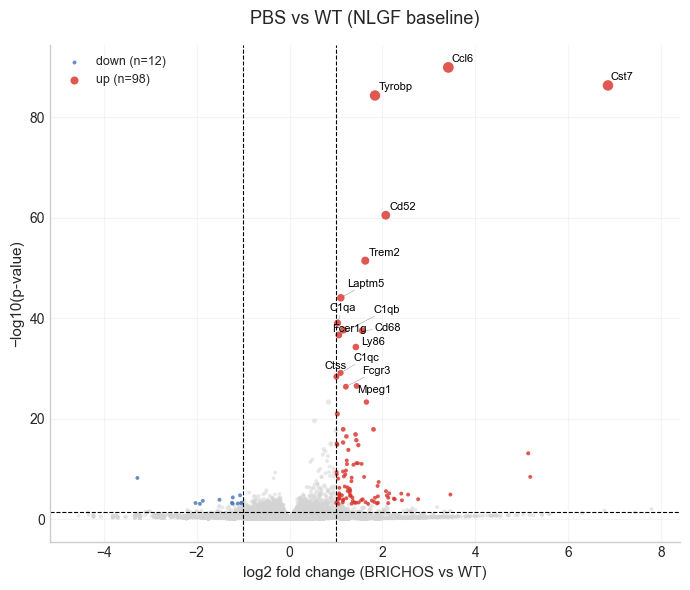

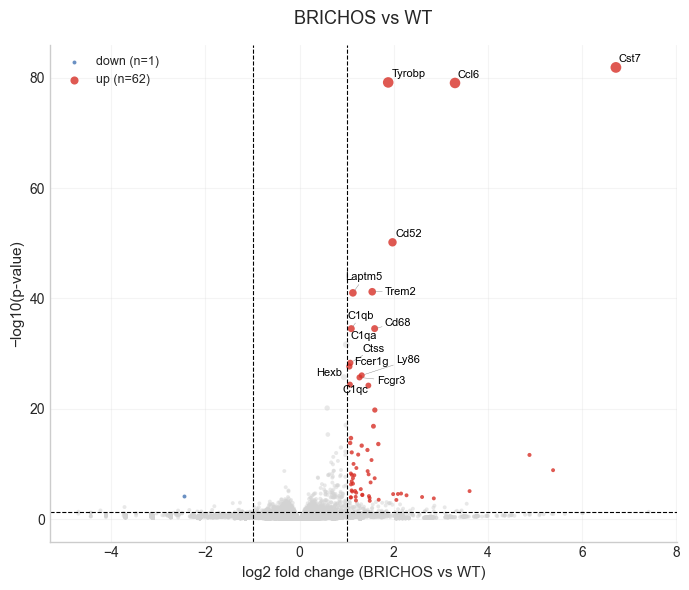

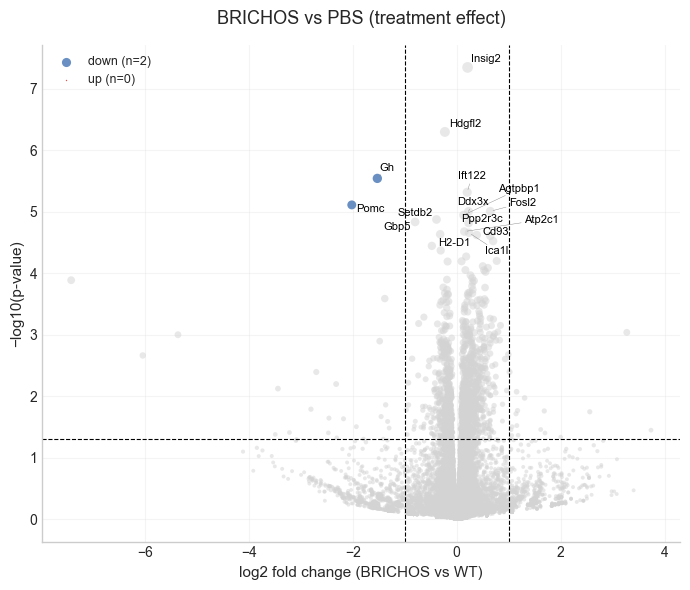

In [12]:
volcano_pretty(res_pbs,  title="PBS vs WT (NLGF baseline)")
volcano_pretty(res_bri,  title="BRICHOS vs WT")
volcano_pretty(res_bri_vs_pbs, title="BRICHOS vs PBS (treatment effect)")

/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


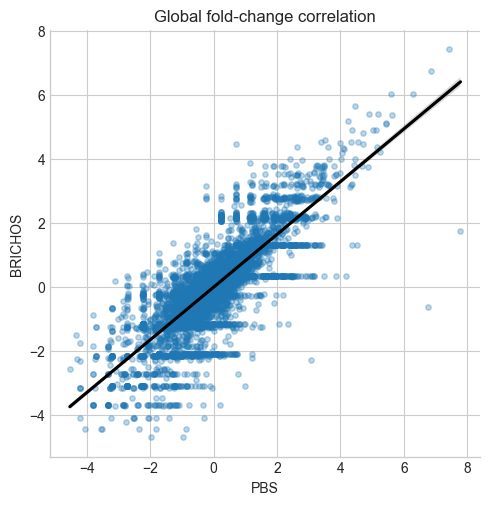

In [13]:
import seaborn as sns

shared = res_pbs.index.intersection(res_bri.index)
df_lfc = pd.DataFrame({
    "PBS": res_pbs.loc[shared, "log2FoldChange"],
    "BRICHOS": res_bri.loc[shared, "log2FoldChange"]
}).dropna()

sns.lmplot(data=df_lfc, x="PBS", y="BRICHOS",
           scatter_kws={"alpha":0.3, "s":15},
           line_kws={"color":"black"})
plt.title("Global fold-change correlation")
plt.show()

In [14]:
corr = df_lfc.corr().iloc[0,1]
print(f"Global correlation = {corr:.2f}")

Global correlation = 0.81


In [15]:
res_bri_vs_pbs.sort_values("padj").head(20)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Insig2,2667.861404,0.211419,0.038658,5.468940,4.527349e-08,0.000668
Hdgfl2,3075.989109,-0.225968,0.044981,-5.023645,5.069980e-07,0.003739
Gh,368.871937,-1.525774,0.326122,-4.678539,2.889261e-06,0.014206
Ift122,1814.887846,0.203191,0.044454,4.570851,4.857468e-06,0.017912
Ppp2r3c,2355.029529,0.230605,0.053331,4.324015,1.532152e-05,0.020545
Pomc,129.947966,-2.017480,0.451268,-4.470695,7.796576e-06,0.020545
Gbp5,187.422800,-0.799041,0.184442,-4.332205,1.476234e-05,0.020545
Fosl2,985.539926,0.647459,0.146505,4.419367,9.899039e-06,0.020545
Ddx3x,12592.928694,0.228357,0.051689,4.417933,9.964920e-06,0.020545
Setdb2,353.369565,-0.387417,0.089006,-4.352725,1.344560e-05,0.020545


/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


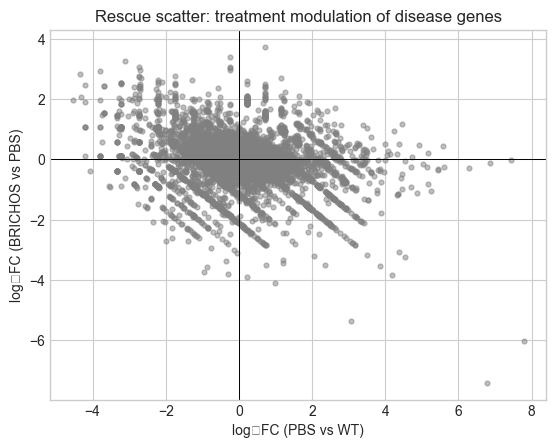

In [17]:
df_compare = pd.DataFrame({
    "log2FC_PBS_vs_WT": res_pbs["log2FoldChange"],
    "log2FC_BRI_vs_PBS": res_bri_vs_pbs["log2FoldChange"]
}).dropna()

plt.scatter(df_compare["log2FC_PBS_vs_WT"],
            df_compare["log2FC_BRI_vs_PBS"],
            s=12, c="grey", alpha=0.5)
plt.axhline(0, color="k", lw=0.7)
plt.axvline(0, color="k", lw=0.7)
plt.xlabel("log₂FC (PBS vs WT)")
plt.ylabel("log₂FC (BRICHOS vs PBS)")
plt.title("Rescue scatter: treatment modulation of disease genes")
plt.show()